In [2]:
from train_model import *
import numpy as np

In [3]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

add_is_test_column(df)

save_model = True
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
write_predictions = False
n_mimo = 4

train_test_ds = Data_selector(Data_selector(df).select_peaks(goodness=3))
df_train = train_test_ds.select_train_test(is_test=False)
df_test = train_test_ds.select_train_test(is_test=True)


In [5]:
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                         "forecast", "status", "season", "datetime", "generation_with_24_delay"]
    
train_errors = []
test_errors = []
m_depth = 5
n_estimators = np.arange(1000, 4000, 200)
for n_est in n_estimators:
    base_feature_selector = Feature_selector(df_train, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_train, ys_train, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=n_est, max_depth=m_depth, learning_rate=0.1)
    model.fit(Xs_train, ys_train)
    ys_pred = model.predict(Xs_train)
    y_pred = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_train)
    rmse_error_train = compute_relative_rmse(y_pred, y_train)
        
    base_feature_selector = Feature_selector(df_test, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_test, ys_test, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    ys_pred = model.predict(Xs_test)
    y_pred = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_test)
    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    
    logger.info(f"train rmse error: {rmse_error_train:0.2f}%, test rmse error: {rmse_error_test:0.2f}%")
    train_errors.append(rmse_error_train)
    test_errors.append(rmse_error_test)


2025-09-27 13:45:26 - train_model - INFO - train rmse error: 1.14%, test rmse error: 2.18%
2025-09-27 13:45:43 - train_model - INFO - train rmse error: 1.03%, test rmse error: 2.17%
2025-09-27 13:46:02 - train_model - INFO - train rmse error: 0.95%, test rmse error: 2.15%
2025-09-27 13:46:20 - train_model - INFO - train rmse error: 0.88%, test rmse error: 2.14%
2025-09-27 13:47:04 - train_model - INFO - train rmse error: 0.82%, test rmse error: 2.14%
2025-09-27 13:47:28 - train_model - INFO - train rmse error: 0.76%, test rmse error: 2.13%
2025-09-27 13:47:51 - train_model - INFO - train rmse error: 0.71%, test rmse error: 2.12%
2025-09-27 13:48:19 - train_model - INFO - train rmse error: 0.67%, test rmse error: 2.12%
2025-09-27 13:49:05 - train_model - INFO - train rmse error: 0.63%, test rmse error: 2.11%
2025-09-27 13:49:33 - train_model - INFO - train rmse error: 0.60%, test rmse error: 2.11%
2025-09-27 13:50:02 - train_model - INFO - train rmse error: 0.57%, test rmse error: 2.11%

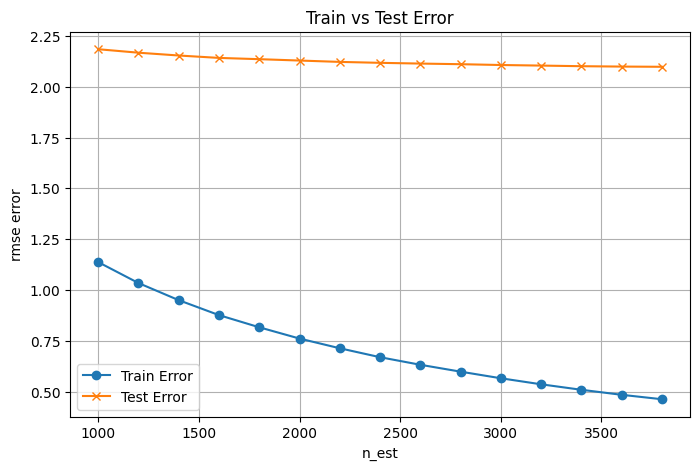

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(n_estimators, train_errors, label='Train Error', marker='o')
plt.plot(n_estimators, test_errors, label='Test Error', marker='x')
plt.xlabel('n_est')
plt.ylabel('rmse error')
plt.title('Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                         "forecast", "status", "season", "datetime", "generation_with_24_delay"]
    
train_errors2 = []
test_errors2 = []
n_est = 1000
m_depths = np.arange(1, 16)
for m_depth in m_depths:
    base_feature_selector = Feature_selector(df_train, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_train, ys_train, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=n_est, max_depth=m_depth, learning_rate=0.1)
    model.fit(Xs_train, ys_train)
    ys_pred = model.predict(Xs_train)
    y_pred = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_train)
    rmse_error_train = compute_relative_rmse(y_pred, y_train)
        
    base_feature_selector = Feature_selector(df_test, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_test, ys_test, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    ys_pred = model.predict(Xs_test)
    y_pred = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_test)
    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    
    logger.info(f"train rmse error: {rmse_error_train:0.2f}%, test rmse error: {rmse_error_test:0.2f}%")
    train_errors2.append(rmse_error_train)
    test_errors2.append(rmse_error_test)

2025-09-27 13:53:54 - train_model - INFO - train rmse error: 3.36%, test rmse error: 3.10%
2025-09-27 13:54:06 - train_model - INFO - train rmse error: 2.58%, test rmse error: 2.47%
2025-09-27 13:54:18 - train_model - INFO - train rmse error: 2.03%, test rmse error: 2.36%
2025-09-27 13:54:32 - train_model - INFO - train rmse error: 1.55%, test rmse error: 2.26%
2025-09-27 13:54:49 - train_model - INFO - train rmse error: 1.14%, test rmse error: 2.18%
2025-09-27 13:55:18 - train_model - INFO - train rmse error: 0.80%, test rmse error: 2.13%
2025-09-27 13:55:37 - train_model - INFO - train rmse error: 0.51%, test rmse error: 2.11%
2025-09-27 13:56:01 - train_model - INFO - train rmse error: 0.31%, test rmse error: 2.13%
2025-09-27 13:56:33 - train_model - INFO - train rmse error: 0.17%, test rmse error: 2.14%
2025-09-27 13:57:39 - train_model - INFO - train rmse error: 0.08%, test rmse error: 2.19%
2025-09-27 13:58:40 - train_model - INFO - train rmse error: 0.03%, test rmse error: 2.22%

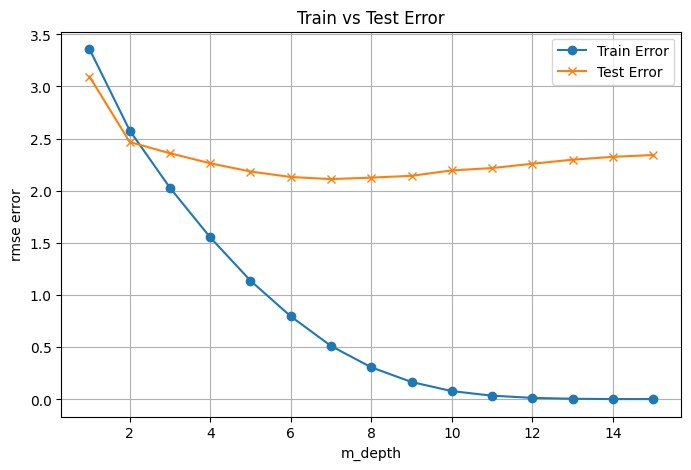

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(m_depths, train_errors2, label='Train Error', marker='o')
plt.plot(m_depths, test_errors2, label='Test Error', marker='x')
plt.xlabel('m_depth')
plt.ylabel('rmse error')
plt.title('Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                 "forecast", "status", "season", "datetime", "generation_with_24_delay"]

train_errors3 = []
test_errors3 = []
m_depth = 7
n_estimators = np.arange(1000, 5000, 200)
for n_est in n_estimators:
    base_feature_selector = Feature_selector(df_train, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_train, ys_train, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=n_est, max_depth=m_depth, learning_rate=0.1)
    model.fit(Xs_train, ys_train)
    ys_pred = model.predict(Xs_train)
    y_pred = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_train)
    rmse_error_train = compute_relative_rmse(y_pred, y_train)

    base_feature_selector = Feature_selector(df_test, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    df_selected = base_feature_selector.df.copy()
    feature_selector = Feature_selector(df_selected, target="generation")
    Xs_test, ys_test, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    ys_pred = model.predict(Xs_test)
    y_pred = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_test)
    rmse_error_test = compute_relative_rmse(y_pred, y_test)

    logger.info(f"train rmse error: {rmse_error_train:0.2f}%, test rmse error: {rmse_error_test:0.2f}%")
    train_errors3.append(rmse_error_train)
    test_errors3.append(rmse_error_test)


2025-09-27 14:14:32 - train_model - INFO - train rmse error: 0.51%, test rmse error: 2.11%
2025-09-27 14:14:53 - train_model - INFO - train rmse error: 0.43%, test rmse error: 2.10%
2025-09-27 14:15:18 - train_model - INFO - train rmse error: 0.36%, test rmse error: 2.10%
2025-09-27 14:15:46 - train_model - INFO - train rmse error: 0.31%, test rmse error: 2.09%
2025-09-27 14:16:15 - train_model - INFO - train rmse error: 0.27%, test rmse error: 2.09%
2025-09-27 14:16:47 - train_model - INFO - train rmse error: 0.23%, test rmse error: 2.09%
2025-09-27 14:17:26 - train_model - INFO - train rmse error: 0.20%, test rmse error: 2.09%
2025-09-27 14:18:04 - train_model - INFO - train rmse error: 0.18%, test rmse error: 2.09%
2025-09-27 14:18:46 - train_model - INFO - train rmse error: 0.16%, test rmse error: 2.09%
2025-09-27 14:19:30 - train_model - INFO - train rmse error: 0.14%, test rmse error: 2.09%
2025-09-27 14:20:16 - train_model - INFO - train rmse error: 0.12%, test rmse error: 2.09%

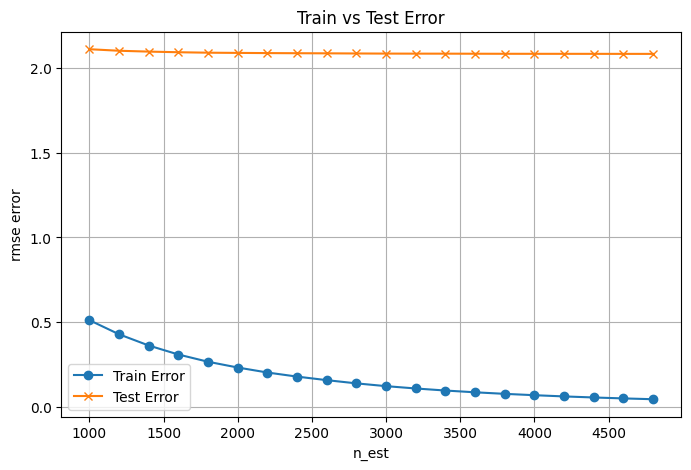

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(n_estimators, train_errors3, label='Train Error', marker='o')
plt.plot(n_estimators, test_errors3, label='Test Error', marker='x')
plt.xlabel('n_est')
plt.ylabel('rmse error')
plt.title('Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()
